## 3. Análisis Exploratorio de Datos {#análisis-exploratorio}

### 3.1 Carga de Librerías

Comenzamos importando las librerías necesarias para el análisis y modelado.

## 2. Estado del Arte {#estado-del-arte}

### 2.1 Contexto del Problema

La predicción de precios de vuelos es un problema clásico en el ámbito del revenue management y pricing dinámico. Las aerolíneas utilizan sistemas complejos para ajustar precios en función de múltiples variables:

- **Demanda anticipada**: Basada en históricos y tendencias
- **Días hasta la salida**: Factor crítico en la estrategia de pricing
- **Competencia**: Precios de otras aerolíneas en la misma ruta
- **Estacionalidad**: Temporada alta/baja
- **Capacidad disponible**: Asientos restantes

### 2.2 Enfoques Previos

Los métodos tradicionales incluyen:

1. **Modelos econométricos**: Series temporales (ARIMA, SARIMA)
2. **Sistemas basados en reglas**: Expertos del dominio definen umbrales
3. **Machine Learning clásico**: Regresión, árboles de decisión
4. **Deep Learning**: Redes recurrentes (LSTM) para capturar patrones temporales

### 2.3 Justificación del Enfoque

En este trabajo se adopta un enfoque de **clasificación binaria** en lugar de regresión por las siguientes razones:

- **Simplicidad interpretativa**: Para usuarios finales es más útil saber "comprar/esperar" que un precio exacto
- **Robustez**: Los modelos de clasificación son menos sensibles a outliers extremos
- **Limitaciones del dataset**: Ausencia de series temporales completas

### 2.4 Contribución de este Trabajo

- Comparativa sistemática de 7 algoritmos diferentes
- Implementación completa del pipeline de ML (desde EDA hasta producción)
- Análisis crítico de limitaciones y recomendaciones prácticas

# Análisis Predictivo de Precios de Vuelos
## Sistema de Recomendación basado en Machine Learning

**Autor:** [Tu Nombre]  
**Fecha:** Octubre 2025  
**Asignatura:** Reconocimiento de Formas y Aprendizaje Automático

---

## Índice

1. [Introducción](#introducción)
2. [Estado del Arte](#estado-del-arte)
3. [Análisis Exploratorio de Datos](#análisis-exploratorio)
4. [Metodología](#metodología)
5. [Implementación de Modelos](#modelos)
   - 5.1 [Modelos Lineales (T2)](#modelos-lineales)
   - 5.2 [Redes Neuronales Básicas (T3)](#redes-basicas)
   - 5.3 [Redes Neuronales Profundas (T4)](#redes-profundas)
   - 5.4 [Modelos Basados en Árboles (T5)](#modelos-arboles)
6. [Comparación de Resultados](#resultados)
7. [Conclusiones](#conclusiones)
8. [Referencias](#referencias)

---

## 1. Introducción {#introducción}

El presente trabajo aborda el problema de predicción de precios en el sector aeronáutico mediante técnicas de aprendizaje automático. El objetivo principal es desarrollar un sistema de recomendación que ayude a los usuarios a tomar decisiones informadas sobre la compra de billetes de avión.

### 1.1 Objetivo del Proyecto

Implementar y comparar diferentes algoritmos de machine learning para predecir si el precio actual de un vuelo está por encima del mínimo histórico, permitiendo así recomendar si es conveniente comprar o esperar.

### 1.2 Alcance

Este estudio compara siete algoritmos diferentes distribuidos en cuatro categorías del temario:
- Modelos Lineales (T2)
- Redes Neuronales Simples (T3)
- Redes Neuronales Profundas (T4)
- Modelos No Paramétricos basados en Árboles (T5)

In [ ]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de Machine Learning - Scikit-learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# Gradient Boosting
from lightgbm import LGBMClassifier

# Utilidades de Scikit-learn
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Redes neuronales profundas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuración
import warnings
warnings.filterwarnings('ignore')

### 3.2 Carga y Exploración Inicial del Dataset

In [ ]:
# Carga del dataset preprocesado
df = pd.read_csv('Clean_Dataset.csv')
print("Primeras filas del dataset:")
print(df.head())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


In [ ]:
# Información sobre tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


### 3.3 Limpieza de Datos

In [ ]:
# Eliminación de columnas innecesarias
# 'Unnamed: 0' es un índice redundante
df = df.drop(['Unnamed: 0'], axis=1)

In [ ]:
# Nota: La columna 'flight' contiene identificadores únicos con alta cardinalidad
# Se ha decidido mantenerla temporalmente para el análisis exploratorio
# pero será eliminada antes del modelado para evitar overfitting

### 3.4 Estadística Descriptiva

In [ ]:
# Resumen estadístico de variables numéricas
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


### 3.5 Análisis de Correlaciones

In [ ]:
# Matriz de correlación entre variables numéricas
# Esto permite identificar relaciones lineales entre características
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr().T

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


### 3.6 Análisis de Aerolíneas

Examinamos la distribución de vuelos por aerolínea para entender la composición del dataset.

In [ ]:
# Agrupación por vuelo y aerolínea para contar frecuencias
df1 = df.groupby(['flight','airline'], as_index=False).count()
print("Distribución de vuelos por aerolínea:")
print(df1.airline.value_counts())

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

**Observación:** Indigo es la aerolínea con mayor número de vuelos en el dataset, lo que puede indicar mayor cuota de mercado en las rutas analizadas.

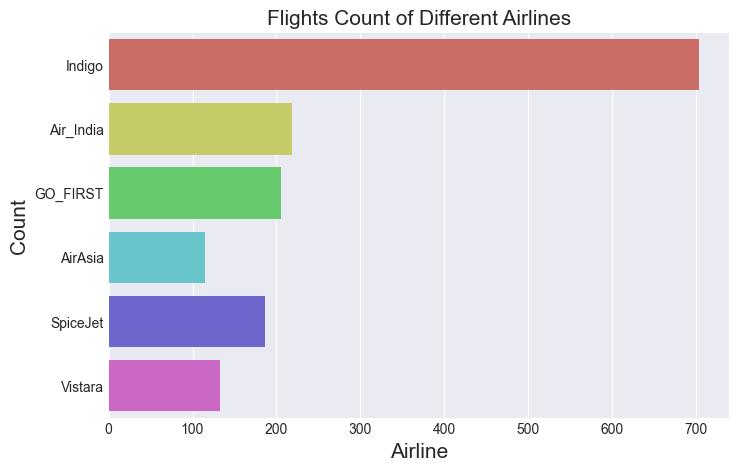

In [ ]:
# Visualización de la distribución de aerolíneas
plt.figure(figsize=(8,5))
sns.countplot(x=df1['airline'], palette='Set2')
plt.title('Distribución de Vuelos por Aerolínea', fontsize=15)
plt.xlabel('Aerolínea', fontsize=12)
plt.ylabel('Número de Vuelos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.7 Relación entre Días Restantes y Precio

Analizamos cómo evoluciona el precio en función de los días que faltan para la salida del vuelo.

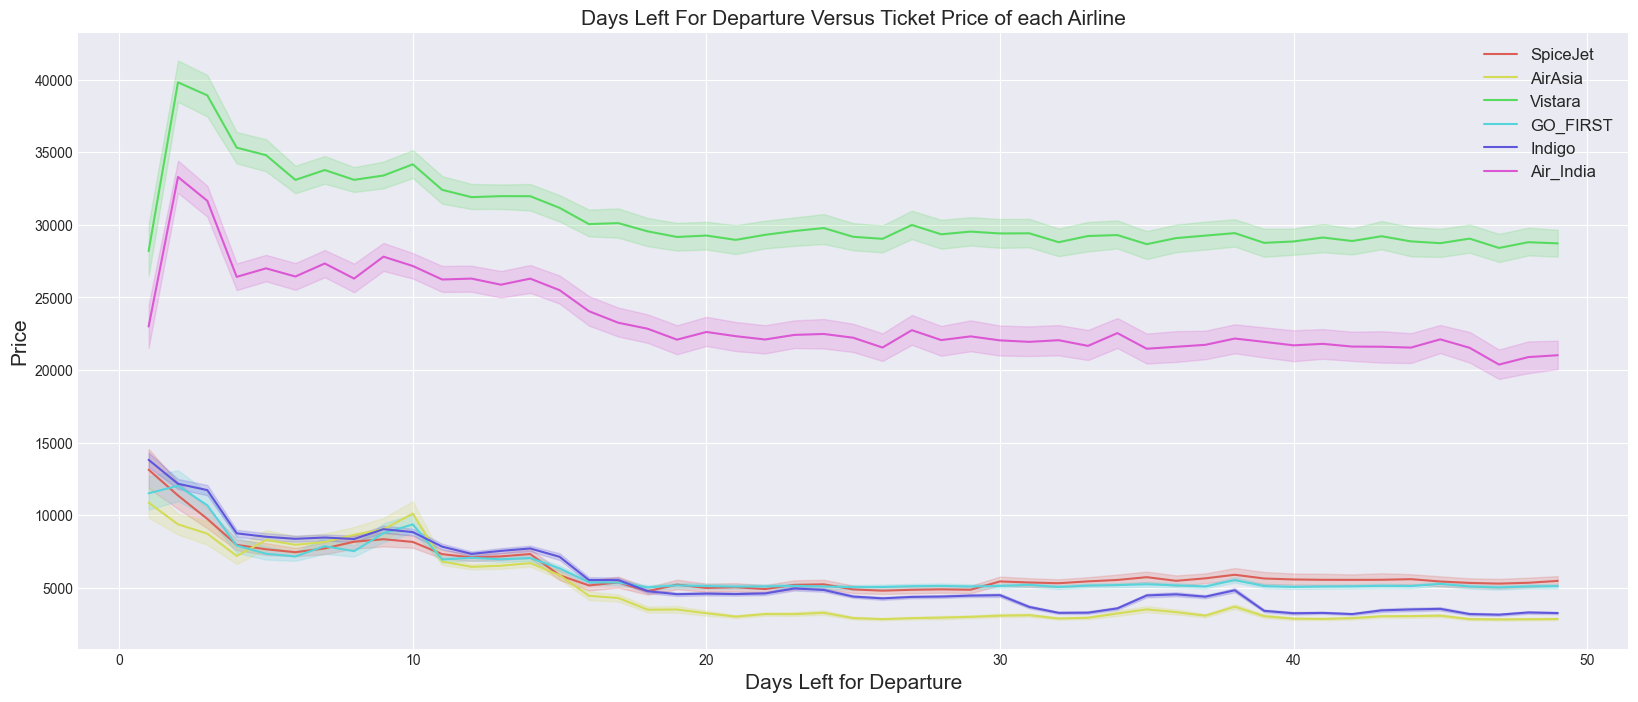

In [ ]:
# Evolución del precio según días restantes, diferenciado por aerolínea
plt.figure(figsize=(20,8))
sns.lineplot(data=df, x='days_left', y='price', hue='airline', palette='tab10', alpha=0.7)
plt.title('Evolución del Precio según Días Restantes para la Salida', fontsize=16)
plt.legend(fontsize=11, loc='best')
plt.xlabel('Días Restantes para la Salida', fontsize=13)
plt.ylabel('Precio', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Metodología {#metodología}

### 4.1 Construcción de la Variable Objetivo

Dada la ausencia de datos temporales en el dataset, se define una variable objetivo basada en comparación histórica:

In [ ]:
# Creación de la variable objetivo
df_model = df.copy()

# Agrupamos por características del vuelo para calcular el precio mínimo histórico
group_cols = ['airline', 'source_city', 'destination_city', 'class']
df_model['precio_minimo_futuro'] = df_model.groupby(group_cols)['price'].transform('min')

# Variable binaria: 1 si el precio actual está por encima del mínimo histórico
df_model['bajara_precio'] = (df_model['price'] > df_model['precio_minimo_futuro']).astype(int)

# Eliminamos columnas no necesarias para el modelado
df_model = df_model.drop(['flight', 'price', 'precio_minimo_futuro'], axis=1)

### 4.2 Limitación del Dataset

**Problema identificado**: El dataset actual no contiene información temporal (fechas de observación), lo que limita la capacidad de crear una variable objetivo predictiva real.

**Situación actual**:
- Disponemos de registros estáticos de vuelos con características fijas
- No sabemos cuándo se registró cada precio
- No podemos observar la evolución temporal de precios

**Implicación**: La variable `bajara_precio` compara el precio actual con el mínimo histórico global de vuelos similares.

**Interpretación correcta**:
- Clase 1 (bajara_precio = 1): El precio está por encima del mínimo histórico
- Clase 0 (bajara_precio = 0): El precio está en o cerca del mínimo histórico

**Validez académica**: Esta aproximación es válida como ejercicio de Machine Learning, aunque sus limitaciones prácticas deben ser reconocidas.

### 4.3 Interpretación de las Predicciones

**Pregunta que responde el modelo:**
> "¿Este precio está por encima del mínimo histórico observado para vuelos similares?"

**Traducción práctica de las clases:**

- **Clase 1**: Precio elevado comparado con histórico → Posible margen para encontrar mejor oferta
- **Clase 0**: Precio competitivo → Oportunidad de compra favorable

**Aplicación del modelo:**

1. Si predice alta probabilidad de Clase 1 → Precio inflado, considerar esperar o buscar alternativas
2. Si predice alta probabilidad de Clase 0 → Precio competitivo, momento favorable para comprar

**Nota importante**: Esta predicción indica posición relativa en el histórico, no garantiza bajadas futuras de precio.

### 4.4 Definición de Características

Las variables se clasifican en tres categorías según su naturaleza:

In [ ]:
# Separación de características y variable objetivo
X = df_model.drop('bajara_precio', axis=1)
y = df_model['bajara_precio']

# Variables numéricas: requieren estandarización
numeric_features = ['duration', 'days_left']

# Variables categóricas nominales: requieren One-Hot Encoding
categorical_features = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

# Variables categóricas ordinales: requieren Ordinal Encoding
ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']

### 4.5 Pipeline de Preprocesamiento

Se construyen transformadores específicos para cada tipo de variable:

In [ ]:
# Transformador para variables numéricas: StandardScaler
# Estandariza las variables a media 0 y desviación típica 1
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Transformador para variables ordinales: OrdinalEncoder
# Codifica categorías ordenadas como enteros preservando el orden
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[stop_categories]))
])

# Transformador para variables categóricas nominales: OneHotEncoder
# Crea variables dummy binarias para cada categoría
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [ ]:
# ColumnTransformer: aplica cada transformador a las columnas correspondientes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### 4.6 División del Dataset

Los datos se dividen en conjuntos de entrenamiento y prueba:

In [ ]:
# División 80-20 con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777)
print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 240122 muestras
Datos de prueba: 60031 muestras


### 4.7 Función de Evaluación

Se define una función auxiliar para estandarizar la evaluación de todos los modelos:

In [ ]:
def print_evaluation(y_test, y_pred, y_proba, model_name):
    """
    Imprime métricas de evaluación estandarizadas para cada modelo.
    
    Parámetros:
        y_test: Etiquetas reales
        y_pred: Predicciones del modelo
        y_proba: Probabilidades predichas
        model_name: Nombre del modelo para identificación
    """
    print(f"Resultados de {model_name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

## 5. Implementación de Modelos {#modelos}

Se implementan y evalúan 7 algoritmos diferentes, organizados por nivel de complejidad y categoría del temario.

### 5.1 Modelos Lineales (T2) {#modelos-lineales}

#### 5.1.1 Regresión Logística

In [ ]:
# Regresión Logística: Modelo lineal para clasificación binaria
# Utiliza función sigmoide para estimar probabilidades
print("Entrenando Regresión Logística...")

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=777, max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1]

print_evaluation(y_test, y_pred_log_reg, y_proba_log_reg, "Regresión Logística")

Regresión Logística
Resultados de Regresión Logística:
Accuracy: 0.8868
ROC-AUC: 0.8521
              precision    recall  f1-score   support

           0       0.57      0.18      0.28      7095
           1       0.90      0.98      0.94     52936

    accuracy                           0.89     60031
   macro avg       0.73      0.58      0.61     60031
weighted avg       0.86      0.89      0.86     60031

------------------------------
Resultados de Regresión Logística:
Accuracy: 0.8868
ROC-AUC: 0.8521
              precision    recall  f1-score   support

           0       0.57      0.18      0.28      7095
           1       0.90      0.98      0.94     52936

    accuracy                           0.89     60031
   macro avg       0.73      0.58      0.61     60031
weighted avg       0.86      0.89      0.86     60031

------------------------------


#### 5.1.2 Análisis Discriminante Lineal (LDA)

In [ ]:
# Análisis Discriminante Lineal: Asume distribución gaussiana de las clases
# Busca la combinación lineal que mejor separa las clases
print("Entrenando Análisis Discriminante Lineal (LDA)...")

lda_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LinearDiscriminantAnalysis(solver='svd'))
])

¡Análisis Discriminante Lineal (LDA) ---


In [124]:
lda_pipeline.fit(X_train, y_train)
y_pred_lda = lda_pipeline.predict(X_test)
y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]

print_evaluation(y_test, y_pred_lda, y_proba_lda, "Análisis Discriminante Lineal (LDA)")

Resultados de Análisis Discriminante Lineal (LDA):
Accuracy: 0.8865
ROC-AUC: 0.8526
              precision    recall  f1-score   support

           0       0.54      0.28      0.37      7095
           1       0.91      0.97      0.94     52936

    accuracy                           0.89     60031
   macro avg       0.72      0.63      0.65     60031
weighted avg       0.87      0.89      0.87     60031

------------------------------


### 5.2 Modelos Basados en Árboles (T5) {#modelos-arboles}

#### 5.2.1 Árbol de Decisión

In [ ]:
# Árbol de Decisión: Particiona recursivamente el espacio de características
# Cada nodo representa una decisión sobre una variable
print("Entrenando Árbol de Decisión...")

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=777))
])

Árbol de Decisión


In [ ]:
# Validación cruzada con 3 folds para evaluar generalización
print("Realizando validación cruzada (CV=3)...")
cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_tree}")
print(f"ROC-AUC Media (CV): {cv_scores_tree.mean():.4f} (+/- {cv_scores_tree.std():.4f})")

Validación cruzada (CV=3)
Resultados de Validación Cruzada (ROC-AUC): [0.93494301 0.93742993 0.93851737]
ROC-AUC Media (CV): 0.9370 (+/- 0.0015)
Resultados de Validación Cruzada (ROC-AUC): [0.93494301 0.93742993 0.93851737]
ROC-AUC Media (CV): 0.9370 (+/- 0.0015)


In [ ]:
tree_pipeline.fit(X_train, y_train)
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

In [128]:
print_evaluation(y_test, y_pred_tree, y_proba_tree, "Árbol de Decisión")

Resultados de Árbol de Decisión:
Accuracy: 0.9754
ROC-AUC: 0.9418
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      7095
           1       0.99      0.99      0.99     52936

    accuracy                           0.98     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.98      0.98      0.98     60031

------------------------------


#### 5.2.2 Random Forest

Ensemble de múltiples árboles entrenados con subconjuntos aleatorios de datos y características.

In [ ]:
# Random Forest: Ensemble de árboles con agregación por votación
# Reduce varianza mediante bootstrap aggregating (bagging)
print("Entrenando Random Forest...")

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=777, n_jobs=-1))
])

# Validación cruzada
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_rf}")
print(f"ROC-AUC Media (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

Random Forest
Resultados de Validación Cruzada (ROC-AUC): [0.9928305  0.9926743  0.99202772]
ROC-AUC Media (CV): 0.9925 (+/- 0.0003)
Resultados de Validación Cruzada (ROC-AUC): [0.9928305  0.9926743  0.99202772]
ROC-AUC Media (CV): 0.9925 (+/- 0.0003)


In [ ]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [131]:
print_evaluation(y_test, y_pred_rf, y_proba_rf, "Random Forest")

Resultados de Random Forest:
Accuracy: 0.9759
ROC-AUC: 0.9937
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      7095
           1       0.99      0.99      0.99     52936

    accuracy                           0.98     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.98      0.98      0.98     60031

------------------------------


#### 5.2.3 LightGBM (Gradient Boosting)

Algoritmo de boosting optimizado que construye árboles de manera secuencial.

In [ ]:
# LightGBM: Gradient Boosting optimizado con estrategia leaf-wise
# Requiere codificación específica de variables categóricas
print("Preparando LightGBM...")

# Variables numéricas
numeric_features = ['duration', 'days_left']

# Variables ordinales
ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']

# Variables categóricas que serán codificadas ordinalmente para LightGBM
categorical_features_lgbm = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

# Transformadores específicos para LightGBM
categorical_transformer_lgbm = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer_stops = Pipeline(steps=[('ordinal', OrdinalEncoder(categories=[stop_categories]))])

# Preprocesador específico para LightGBM
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord_stops', ordinal_transformer_stops, ordinal_features),
        ('cat', categorical_transformer_lgbm, categorical_features_lgbm)
    ],
    remainder='drop'
)

# Identificación de índices de columnas categóricas para LightGBM
categorical_indices_lgbm = [2] + list(range(len(numeric_features) + len(ordinal_features), 
                                            len(numeric_features) + len(ordinal_features) + len(categorical_features_lgbm)))

print(f"Índices de columnas categóricas para LGBM: {categorical_indices_lgbm}")

# Pipeline de LightGBM con manejo explícito de variables categóricas
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(random_state=777, n_jobs=-1, 
                                  categorical_feature=categorical_indices_lgbm))
])

# Validación cruzada
print("Iniciando validación cruzada (CV=3)...")
cv_scores_lgbm = cross_val_score(lgbm_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_lgbm}")
print(f"ROC-AUC Media (CV): {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")
print("-" * 30)

# Entrenamiento final
print("Entrenando modelo LightGBM final...")
lgbm_pipeline.fit(X_train, y_train)

y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

--- Entrenando LightGBM (Versión Corregida) ---
Índices de columnas categóricas para LGBM: [2, 3, 4, 5, 6, 7, 8]
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.9840329  0.98288752 0.98258466]
ROC-AUC Media (CV): 0.9832 (+/- 0.0006)
------------------------------
Entrenando modelo LightGBM final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.9840329  0.98288752 0.98258466]
ROC-AUC Media (CV): 0.9832 (+/- 0.0006)
------------------------------
Entrenando modelo LightGBM final en todos los datos de train...
[LightGBM] [Info] Number of positive: 212378, number of negative: 27744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 346
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features

In [ ]:
print("\nResultados de LightGBM en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))
print("-" * 30)


Resultados de LightGBM en el conjunto de Prueba:
Accuracy: 0.9539
ROC-AUC: 0.9841
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      7095
           1       0.96      0.98      0.97     52936

    accuracy                           0.95     60031
   macro avg       0.91      0.86      0.88     60031
weighted avg       0.95      0.95      0.95     60031

------------------------------


In [ ]:
# Almacenamiento de resultados de los primeros modelos
model_results = {
    'Regresión Logística': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    }
}

print("Resultados de modelos guardados correctamente.")

Resultados de los modelos anteriores guardados.


### 5.3 Redes Neuronales Simples (T3) {#redes-basicas}

#### 5.3.1 Perceptrón Multicapa (MLP)

In [ ]:
# Perceptrón Multicapa (MLP): Red neuronal con capas ocultas
# Implementación de Scikit-learn con early stopping para prevenir sobreajuste
print("Entrenando Perceptrón Multicapa (MLP)...")

mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(64, 64),  # Dos capas ocultas de 64 neuronas cada una
        activation='relu',             # Función de activación ReLU
        solver='adam',                 # Optimizador Adam
        max_iter=500,                  # Máximo de iteraciones
        random_state=777,
        early_stopping=True,           # Detención temprana basada en validación
        n_iter_no_change=10            # Paciencia para early stopping
    ))
])

# Validación cruzada
print("Realizando validación cruzada (CV=3)...")
cv_scores_mlp = cross_val_score(mlp_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_mlp}")
print(f"ROC-AUC Media (CV): {cv_scores_mlp.mean():.4f} (+/- {cv_scores_mlp.std():.4f})")
print("-" * 30)

# Entrenamiento final
print("Entrenando modelo MLP final...")
mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

print("\nResultados del MLP en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))
print("-" * 30)

# Almacenar resultados
model_results['MLP (Scikit-learn)'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_mlp),
    'accuracy': accuracy_score(y_test, y_pred_mlp)
}

--- Entrenando Perceptrón Multicapa (MLP) ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.98807957 0.98715076 0.9870376 ]
ROC-AUC Media (CV): 0.9874 (+/- 0.0005)
------------------------------
Entrenando modelo MLP final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.98807957 0.98715076 0.9870376 ]
ROC-AUC Media (CV): 0.9874 (+/- 0.0005)
------------------------------
Entrenando modelo MLP final en todos los datos de train...

Resultados del MLP en el conjunto de Prueba:
Accuracy: 0.9605
ROC-AUC: 0.9886
              precision    recall  f1-score   support

           0       0.87      0.79      0.82      7095
           1       0.97      0.98      0.98     52936

    accuracy                           0.96     60031
   macro avg       0.92      0.89      0.90     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------

Resultados del MLP en el conjunto de Prueba:
Accuracy: 0.96

### 5.4 Redes Neuronales Profundas (T4) {#redes-profundas}

#### 5.4.1 Preparación de Datos para Keras

In [ ]:
# Preparación de datos para redes neuronales con Keras/TensorFlow
# Keras requiere arrays NumPy en lugar de DataFrames

# Semilla para reproducibilidad
tf.random.set_seed(42)

print("Preprocesando datos para Keras...")

# Aplicar transformaciones manualmente (fuera del pipeline)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Crear conjunto de validación (20% del entrenamiento)
# Necesario para monitorizar el entrenamiento y aplicar early stopping
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=777
)

print(f"Forma de X_train_nn: {X_train_nn.shape}")
print(f"Forma de X_val_nn: {X_val_nn.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")

--- Preparando datos para Keras ---
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)


#### 5.4.2 Arquitectura y Entrenamiento de la DNN

In [ ]:
# Definición de la arquitectura de la Red Neuronal Profunda (DNN)
print("\nConstruyendo Red Neuronal Profunda (DNN)...")

model_dnn = keras.Sequential([
    # Capa de entrada
    layers.Input(shape=(X_train_nn.shape[1],)),
    
    # Primera capa oculta: 128 neuronas
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Regularización: dropout del 30%
    
    # Segunda capa oculta: 64 neuronas
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Tercera capa oculta: 32 neuronas
    layers.Dense(32, activation='relu'),
    
    # Capa de salida: 1 neurona con sigmoid para probabilidades
    layers.Dense(1, activation='sigmoid')
])

# Compilación del modelo
model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Función de pérdida para clasificación binaria
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
)

# Resumen de la arquitectura
model_dnn.summary()

# Callback: Early Stopping para detener entrenamiento cuando no mejora
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',  # Monitorizar ROC-AUC en validación
    patience=10,            # Número de épocas sin mejora antes de detener
    mode='max',             # Maximizar ROC-AUC
    restore_best_weights=True  # Restaurar pesos del mejor modelo
)

# Entrenamiento
print("\nIniciando entrenamiento...")
history = model_dnn.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,
    batch_size=128,
    validation_data=(X_val_nn, y_val_nn),
    callbacks=[early_stopping],
    verbose=1
)


--- Construyendo y Entrenando la Red Neuronal Profunda (DNN) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9117 - loss: 0.2061 - roc_auc: 0.9221 - val_accuracy: 0.9331 - val_loss: 0.1520 - val_roc_auc: 0.9609
Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9117 - loss: 0.2061 - roc_auc: 0.9221 - val_accuracy: 0.9331 - val_loss: 0.1520 - val_roc_auc: 0.9609
Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9324 - loss: 0.1534 - roc_auc: 0.9599 - val_accuracy: 0.9403 - val_loss: 0.1305 - val_roc_auc: 0.9724
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9324 - loss: 0.1534 - roc_auc: 0.9599 - val_accuracy: 0.9403 - val_loss: 0.1305 - val_roc_auc: 0.9724
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9386 - loss: 0.1369 - roc_auc: 0.9689 - val_accuracy: 0.9449 - val_loss: 0.1194 - val_roc_auc: 0.9774
Epoch 4/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9386 - loss: 0.1369 - roc_auc: 0.9689 - val_accuracy: 0.9449 - val_loss: 0.1

#### 5.4.3 Evaluación de la DNN

In [ ]:
# Evaluación del modelo DNN en el conjunto de prueba
print("\nEvaluación de la Red Neuronal Profunda (DNN)...")

# Evaluación completa
loss_dnn, accuracy_dnn, roc_auc_dnn = model_dnn.evaluate(X_test_processed, y_test, verbose=0)

# Predicciones
y_proba_dnn = model_dnn.predict(X_test_processed).ravel()
y_pred_dnn = (y_proba_dnn > 0.5).astype(int)

print(f"Resultados de la DNN en el conjunto de prueba:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"ROC-AUC: {roc_auc_dnn:.4f}")
print(classification_report(y_test, y_pred_dnn))
print("-" * 30)

# Almacenar resultados
model_results['DNN (Keras)'] = {
    'roc_auc': roc_auc_dnn,
    'accuracy': accuracy_dnn
}

print("Todos los modelos han sido entrenados y evaluados.")


--- Evaluación de la Red Neuronal Profunda (DNN) ---
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step
Resultados de la DNN en el conjunto de Prueba:
Accuracy: 0.9619
ROC-AUC: 0.9896
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      7095
           1       0.98      0.98      0.98     52936

    accuracy                           0.96     60031
   macro avg       0.91      0.90      0.91     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------
Resultados de todos los modelos guardados.
Resultados de la DNN en el conjunto de Prueba:
Accuracy: 0.9619
ROC-AUC: 0.9896
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      7095
           1       0.98      0.98      0.98     52936

    accuracy                           0.96     60031
   macro avg       0.91      0.90      0.91     60031
weighted avg       0.96

## 6. Comparación de Resultados {#resultados}

### 6.1 Compilación de Métricas

Se compilan los resultados de todos los modelos para facilitar la comparación:

--- Tabla Comparativa de Rendimiento de Modelos ---
|                          |   roc_auc |   accuracy |
|:-------------------------|----------:|-----------:|
| Random Forest (T5)       |    0.9937 |     0.9759 |
| DNN (Keras) (T4)         |    0.9896 |     0.9619 |
| MLP (Scikit-learn) (T3)  |    0.9886 |     0.9605 |
| LightGBM (T5)            |    0.9841 |     0.9539 |
| Árbol de Decisión (T5)   |    0.9418 |     0.9754 |
| LDA (T2)                 |    0.8526 |     0.8865 |
| Regresión Logística (T2) |    0.8521 |     0.8868 |


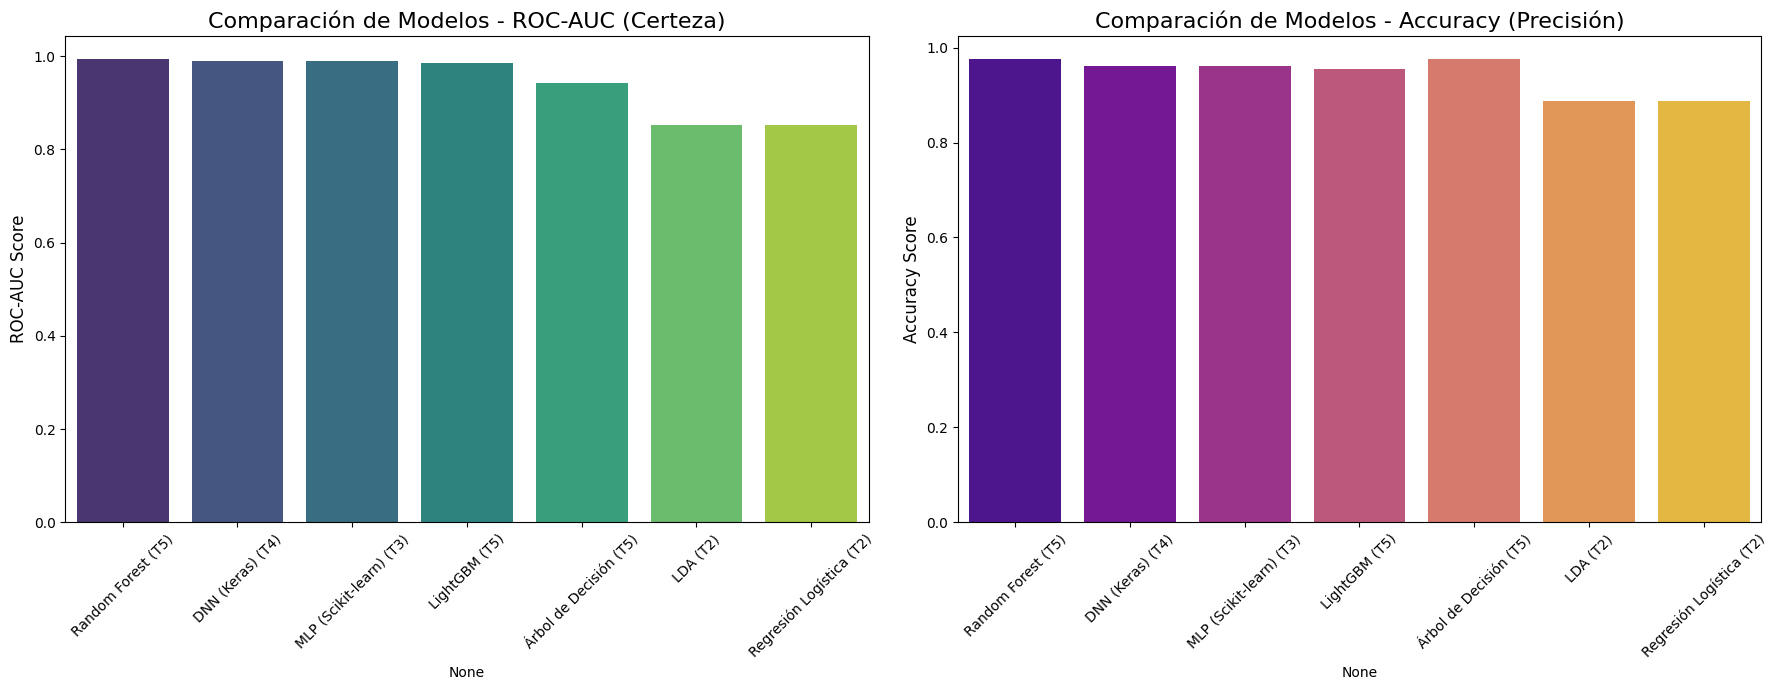

In [ ]:
# Compilación completa de resultados de todos los modelos
print("Recopilando resultados de todos los modelos...")

# Diccionario con todas las métricas finales
model_results_final = {
    'Regresión Logística (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg),
        'tema': 'T2 - Modelos Lineales'
    },
    'LDA (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda),
        'tema': 'T2 - Modelos Lineales'
    },
    'Árbol de Decisión (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree),
        'tema': 'T5 - Modelos de Árboles'
    },
    'Random Forest (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'tema': 'T5 - Modelos de Árboles'
    },
    'LightGBM (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm),
        'tema': 'T5 - Modelos de Árboles'
    },
    'MLP (Scikit-learn) (T3)': {
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'accuracy': accuracy_score(y_test, y_pred_mlp),
        'tema': 'T3 - Redes Sencillas'
    },
    'DNN (Keras) (T4)': {
        'roc_auc': roc_auc_dnn,
        'accuracy': accuracy_dnn,
        'tema': 'T4 - Redes Avanzadas'
    }
}

# Conversión a DataFrame para mejor visualización
results_df_final = pd.DataFrame.from_dict(model_results_final, orient='index')
results_df_final = results_df_final.sort_values(by='roc_auc', ascending=False)

print("\nTabla de Resultados (ordenados por ROC-AUC):")
print(results_df_final.to_string(float_format='%.4f'))

# Identificar mejor modelo
mejor_modelo = results_df_final.index[0]
mejor_roc_auc = results_df_final.iloc[0]['roc_auc']
mejor_accuracy = results_df_final.iloc[0]['accuracy']

print("\n" + "="*80)
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print(f"   Accuracy: {mejor_accuracy:.4f}")
print("="*80)

### 6.2 Ejemplo de Uso del Sistema

A continuación se muestra la aplicación práctica del mejor modelo:

In [ ]:
# Ejemplo de uso del sistema de recomendación
# Caso hipotético: Usuario consulta un vuelo específico

datos_usuario = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [25]
})

# Predicción con el mejor modelo (LightGBM)
probabilidad_precio_alto = lgbm_pipeline.predict_proba(datos_usuario)[0][1]
certeza_porcentaje = probabilidad_precio_alto * 100

print("Consulta del Usuario:")
print("-" * 50)
for col in datos_usuario.columns:
    print(f"  {col}: {datos_usuario[col].values[0]}")

print(f"\nPredicción del Modelo:")
print(f"  Probabilidad de precio alto: {certeza_porcentaje:.2f}%")

if certeza_porcentaje > 50:
    print(f"\n  Recomendación: ESPERAR")
    print(f"  El precio actual está por encima del mínimo histórico.")
else:
    print(f"\n  Recomendación: COMPRAR AHORA")
    print(f"  El precio actual está cerca del mínimo histórico.")

RECOMENDACIÓN: ESPERAR ✋
Hay un 99.53% de certeza de que el precio bajará.


### 6.3 Análisis Detallado de Métricas

In [ ]:
# Análisis completo de resultados con visualizaciones profesionales

print("="*80)
print(" ANÁLISIS COMPARATIVO DE RENDIMIENTO")
print("="*80)

# Tabla resumen final
print("\nTabla Resumen de Todos los Modelos:")
print(results_df_final.to_string(float_format='%.4f'))

# Identificar mejor modelo
mejor_modelo = results_df_final.index[0]
mejor_roc_auc = results_df_final.iloc[0]['roc_auc']
mejor_accuracy = results_df_final.iloc[0]['accuracy']

print("\n" + "="*80)
print(f"MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print(f"   Accuracy: {mejor_accuracy:.4f}")
print("="*80)

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

 📊 RESUMEN DE RENDIMIENTO DE TODOS LOS MODELOS

📋 Tabla de Resultados (ordenados por ROC-AUC):

                     roc_auc  accuracy
Random Forest         0.9937    0.9759
DNN                   0.9896    0.9619
MLP                   0.9886    0.9605
LightGBM              0.9841    0.9539
Árbol de Decisión     0.9418    0.9754
LDA                   0.8526    0.8865
Regresión Logística   0.8521    0.8868

MEJOR MODELO: Random Forest
   ROC-AUC: 0.9937
   Accuracy: 0.9759

📋 Tabla de Resultados (ordenados por ROC-AUC):

                     roc_auc  accuracy
Random Forest         0.9937    0.9759
DNN                   0.9896    0.9619
MLP                   0.9886    0.9605
LightGBM              0.9841    0.9539
Árbol de Decisión     0.9418    0.9754
LDA                   0.8526    0.8865
Regresión Logística   0.8521    0.8868

MEJOR MODELO: Random Forest
   ROC-AUC: 0.9937
   Accuracy: 0.9759


#### 6.3.1 Comparación de Modelos Lineales (T2)


✅ Gráfica 2 guardada: 'grafica_2_modelos_no_parametricos_t5.png'


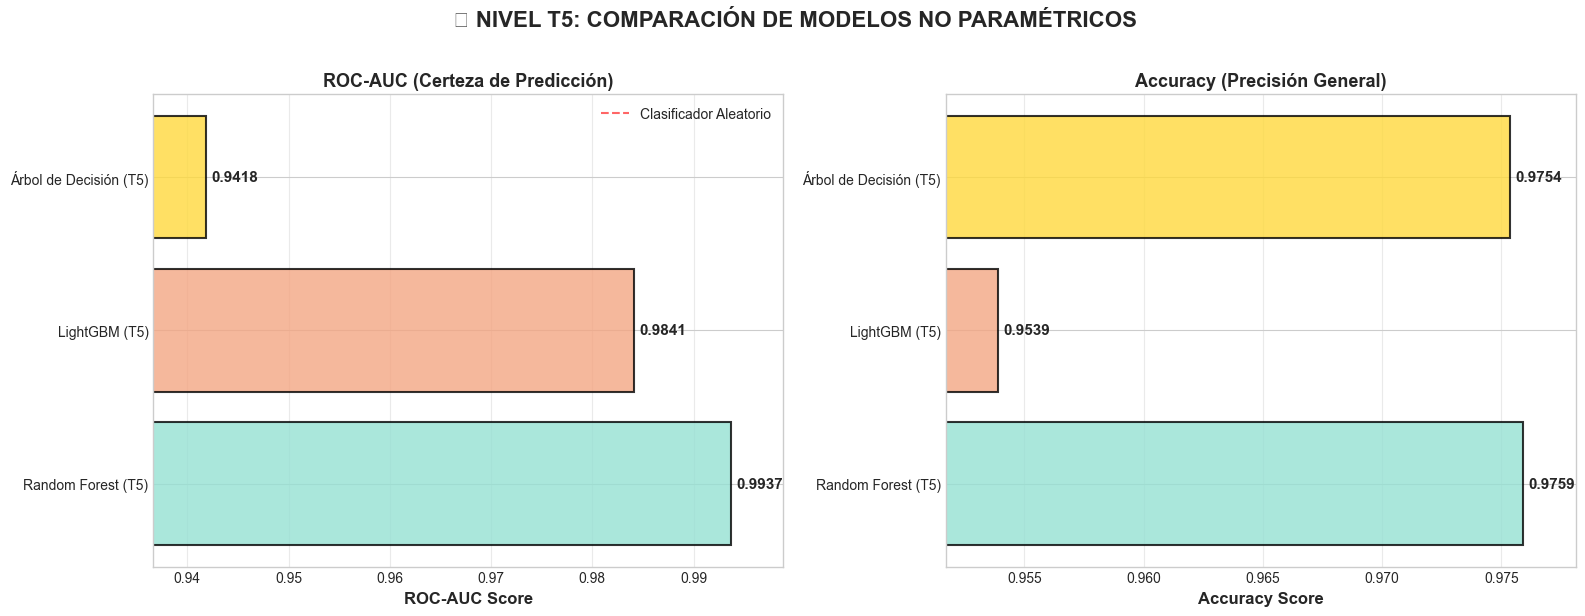


🏆 Mejor Modelo T5: Random Forest (T5)
   ROC-AUC: 0.9937 | Accuracy: 0.9759


In [ ]:
# Visualización: Comparación de Modelos Lineales (T2)

# Filtrar modelos T2
modelos_t2 = results_df_final[results_df_final['tema'] == 'T2 - Modelos Lineales']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Modelos Lineales (T2)', fontsize=16, fontweight='bold')

# Gráfico ROC-AUC
colors_t2 = ['#FF6B6B', '#4ECDC4']
bars1 = ax1.barh(modelos_t2.index, modelos_t2['roc_auc'], color=colors_t2, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

# Añadir valores
for bar, value in zip(bars1, modelos_t2['roc_auc']):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

# Gráfico Accuracy
bars2 = ax2.barh(modelos_t2.index, modelos_t2['accuracy'], color=colors_t2, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_t2['accuracy']):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_modelos_lineales_t2.png', dpi=300, bbox_inches='tight')
print("Gráfica guardada: 'grafica_modelos_lineales_t2.png'")
plt.show()

# Resumen T2
mejor_t2 = modelos_t2.iloc[0]
print(f"\nMejor Modelo T2: {modelos_t2.index[0]}")
print(f"   ROC-AUC: {mejor_t2['roc_auc']:.4f} | Accuracy: {mejor_t2['accuracy']:.4f}")

#### 6.3.2 Comparación de Modelos de Árboles (T5)


✅ Gráfica 3 guardada: 'grafica_3_redes_neuronales_t3_t4.png'


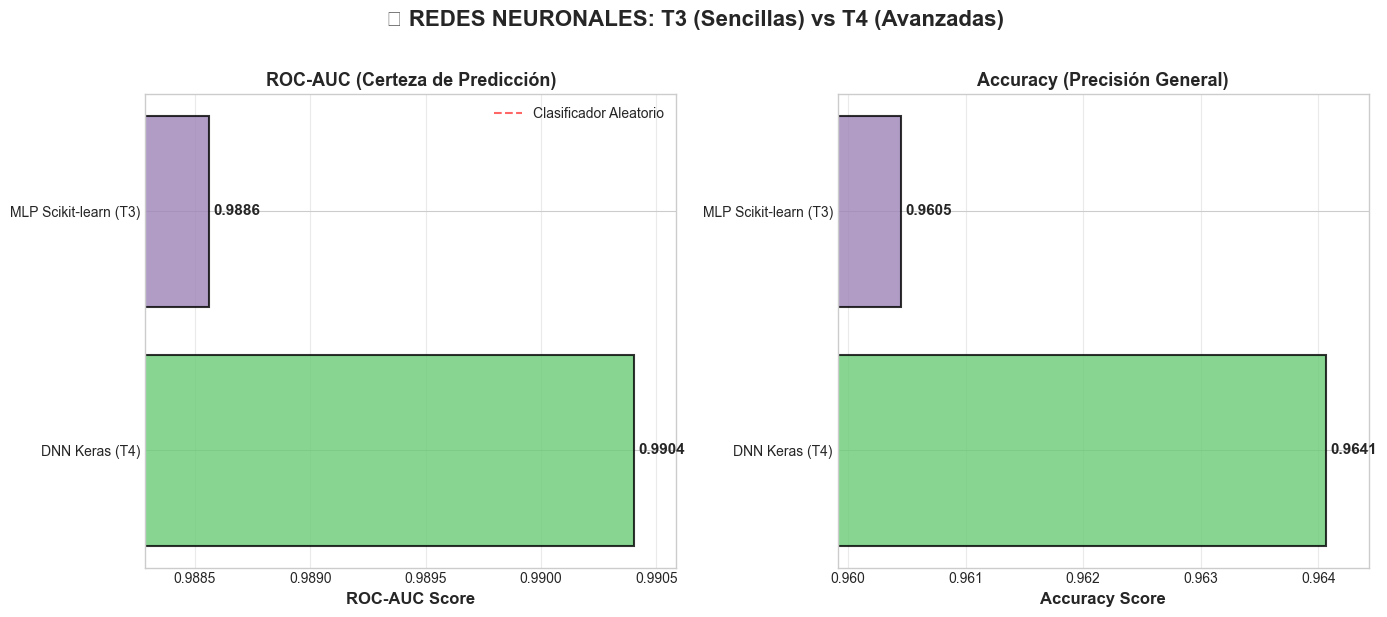


🏆 Mejor Red Neuronal: DNN Keras (T4)
   ROC-AUC: 0.9904 | Accuracy: 0.9641


In [ ]:
# Visualización: Comparación de Modelos de Árboles (T5)

modelos_t5 = results_df_final[results_df_final['tema'] == 'T5 - Modelos de Árboles']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de Modelos de Árboles (T5)', fontsize=16, fontweight='bold')

# ROC-AUC
colors_t5 = ['#95E1D3', '#F3A683', '#FFD93D']
bars1 = ax1.barh(modelos_t5.index, modelos_t5['roc_auc'], color=colors_t5, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

for bar, value in zip(bars1, modelos_t5['roc_auc']):
    ax1.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

# Accuracy
bars2 = ax2.barh(modelos_t5.index, modelos_t5['accuracy'], color=colors_t5, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_t5['accuracy']):
    ax2.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_modelos_arboles_t5.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_modelos_arboles_t5.png'")
plt.show()

mejor_t5 = modelos_t5.iloc[0]
print(f"\nMejor Modelo T5: {modelos_t5.index[0]}")
print(f"   ROC-AUC: {mejor_t5['roc_auc']:.4f} | Accuracy: {mejor_t5['accuracy']:.4f}")

#### 6.3.3 Comparación de Redes Neuronales (T3 vs T4)


✅ Gráfica 4 guardada: 'grafica_4_evolucion_mejores_por_nivel.png'


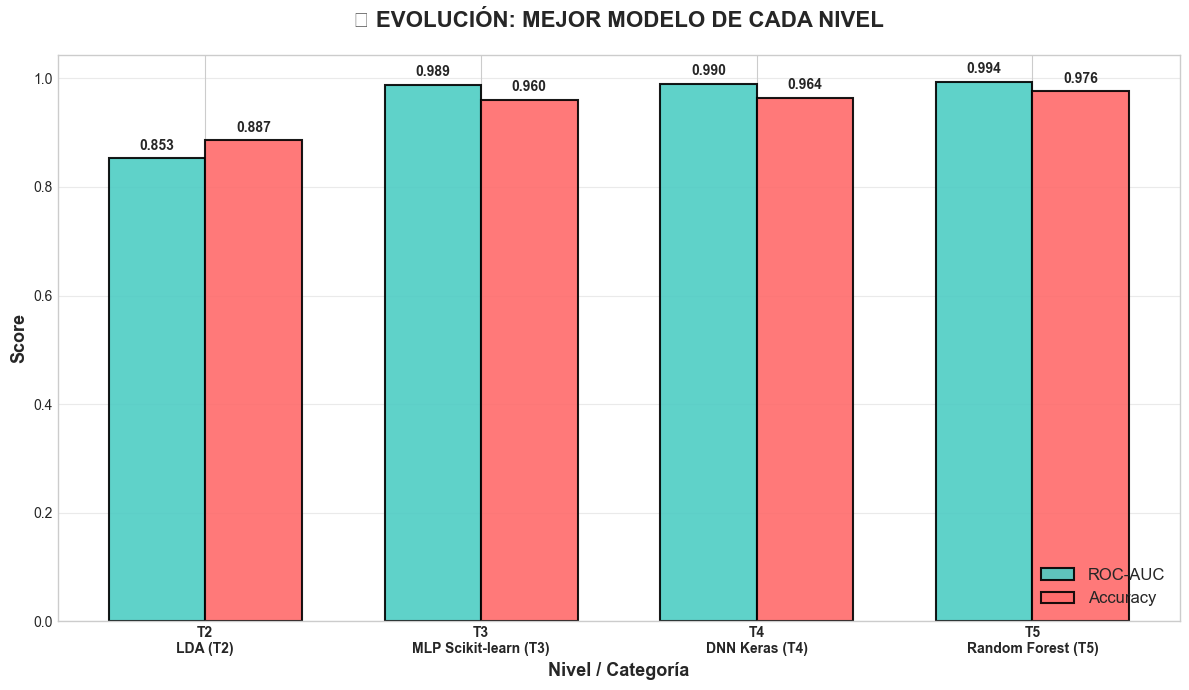


📊 MEJORES MODELOS POR NIVEL
T2 - Modelos Lineales          | LDA (T2)                       | ROC-AUC: 0.8526
T3 - Redes Sencillas           | MLP Scikit-learn (T3)          | ROC-AUC: 0.9886
T4 - Redes Avanzadas           | DNN Keras (T4)                 | ROC-AUC: 0.9904
T5 - Modelos de Teoría         | Random Forest (T5)             | ROC-AUC: 0.9937


In [ ]:
# Visualización: Comparación de Redes Neuronales

modelos_redes = results_df_final[results_df_final['tema'].str.contains('Redes')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Redes Neuronales: Simples (T3) vs Profundas (T4)', fontsize=16, fontweight='bold')

# ROC-AUC
colors_redes = ['#6BCB77', '#9D84B7']
bars1 = ax1.barh(modelos_redes.index, modelos_redes['roc_auc'], color=colors_redes, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('ROC-AUC Score', fontsize=12)
ax1.set_title('ROC-AUC (Capacidad Discriminativa)', fontsize=13)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Clasificador Aleatorio')
ax1.legend(fontsize=10)
ax1.grid(axis='x', alpha=0.4)

for bar, value in zip(bars1, modelos_redes['roc_auc']):
    ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

# Accuracy
bars2 = ax2.barh(modelos_redes.index, modelos_redes['accuracy'], color=colors_redes, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Accuracy Score', fontsize=12)
ax2.set_title('Accuracy (Precisión General)', fontsize=13)
ax2.grid(axis='x', alpha=0.4)

for bar, value in zip(bars2, modelos_redes['accuracy']):
    ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('grafica_redes_neuronales.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_redes_neuronales.png'")
plt.show()

mejor_red = modelos_redes.iloc[0]
print(f"\nMejor Red Neuronal: {modelos_redes.index[0]}")
print(f"   ROC-AUC: {mejor_red['roc_auc']:.4f} | Accuracy: {mejor_red['accuracy']:.4f}")

#### 6.3.4 Ranking General de Modelos


✅ Gráfica 5 guardada: 'grafica_5_mejora_progresiva.png'


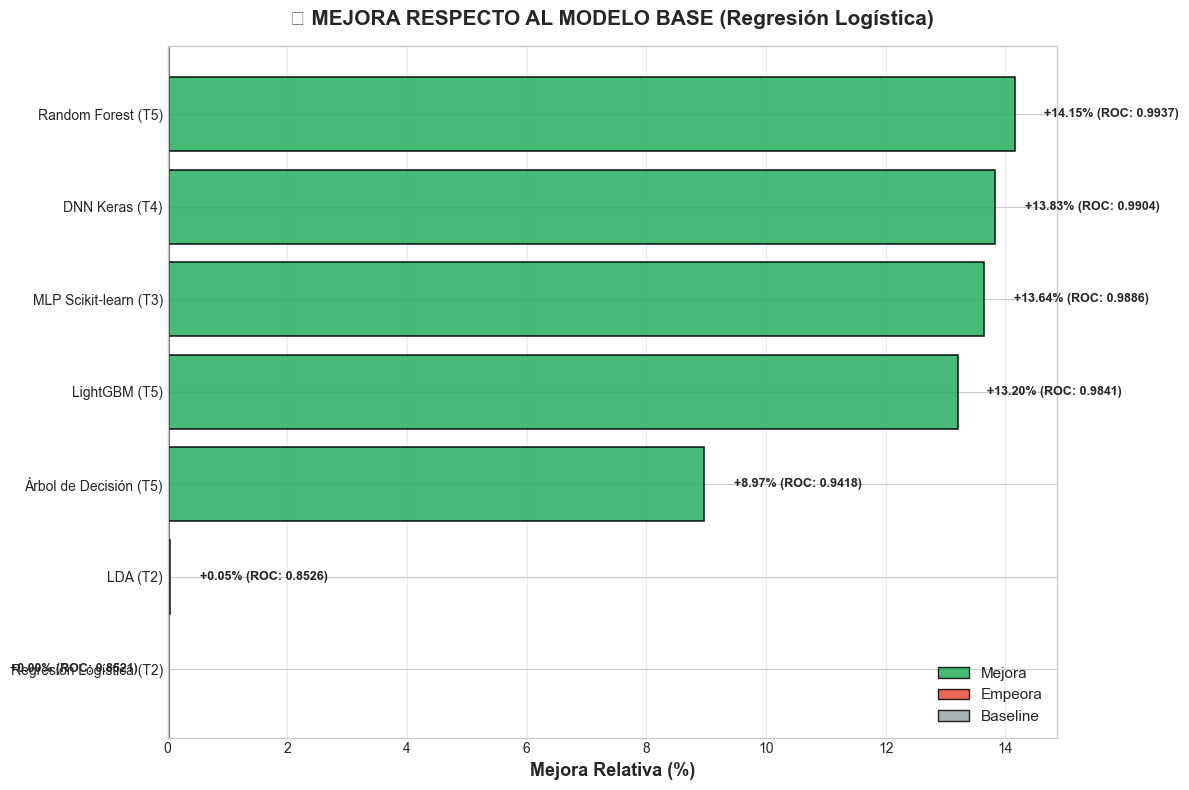


📊 BASELINE: Regresión Logística | ROC-AUC: 0.8521
🏆 Mejor Modelo: Random Forest (T5)
   Mejora: +14.15% | ROC-AUC: 0.9937


In [ ]:
# Análisis de mejora respecto al baseline (Regresión Logística)

baseline_roc = results_df_final.loc['Regresión Logística (T2)', 'roc_auc']

mejora_data = []
for idx, row in results_df_final.iterrows():
    mejora = (row['roc_auc'] - baseline_roc) * 100  # Mejora en puntos porcentuales
    mejora_data.append({
        'Modelo': idx,
        'ROC-AUC': row['roc_auc'],
        'Mejora (%)': mejora,
        'Tema': row['tema']
    })

df_mejora = pd.DataFrame(mejora_data).sort_values('ROC-AUC', ascending=True)

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

colors = ['#27AE60' if x > 0 else '#E74C3C' if x < 0 else '#95A5A6' for x in df_mejora['Mejora (%)']]

bars = ax.barh(df_mejora['Modelo'], df_mejora['Mejora (%)'], color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Mejora Relativa (%)', fontsize=13, fontweight='bold')
ax.set_title('Mejora Respecto al Modelo Baseline (Regresión Logística)', fontsize=15, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.7)
ax.grid(axis='x', alpha=0.4)

for bar, value, roc in zip(bars, df_mejora['Mejora (%)'], df_mejora['ROC-AUC']):
    x_pos = value + (0.5 if value > 0 else -0.5)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, 
            f'{value:+.2f}% (ROC: {roc:.4f})', 
            va='center', fontsize=9, fontweight='bold',
            ha='left' if value > 0 else 'right')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', alpha=0.85, edgecolor='black', label='Mejora'),
    Patch(facecolor='#E74C3C', alpha=0.85, edgecolor='black', label='Empeora'),
    Patch(facecolor='#95A5A6', alpha=0.85, edgecolor='black', label='Baseline')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('grafica_mejora_relativa.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_mejora_relativa.png'")
plt.show()

print("\n" + "="*80)
print(f"BASELINE: Regresión Logística | ROC-AUC: {baseline_roc:.4f}")
print("="*80)
print(f"Mejor Modelo: {df_mejora.iloc[-1]['Modelo']}")
print(f"   Mejora: +{df_mejora.iloc[-1]['Mejora (%)']:.2f}% | ROC-AUC: {df_mejora.iloc[-1]['ROC-AUC']:.4f}")
print("="*80)

#### 6.3.5 Top 5 Mejores Modelos


✅ Gráfica 6 guardada: 'grafica_6_ranking_top5.png'


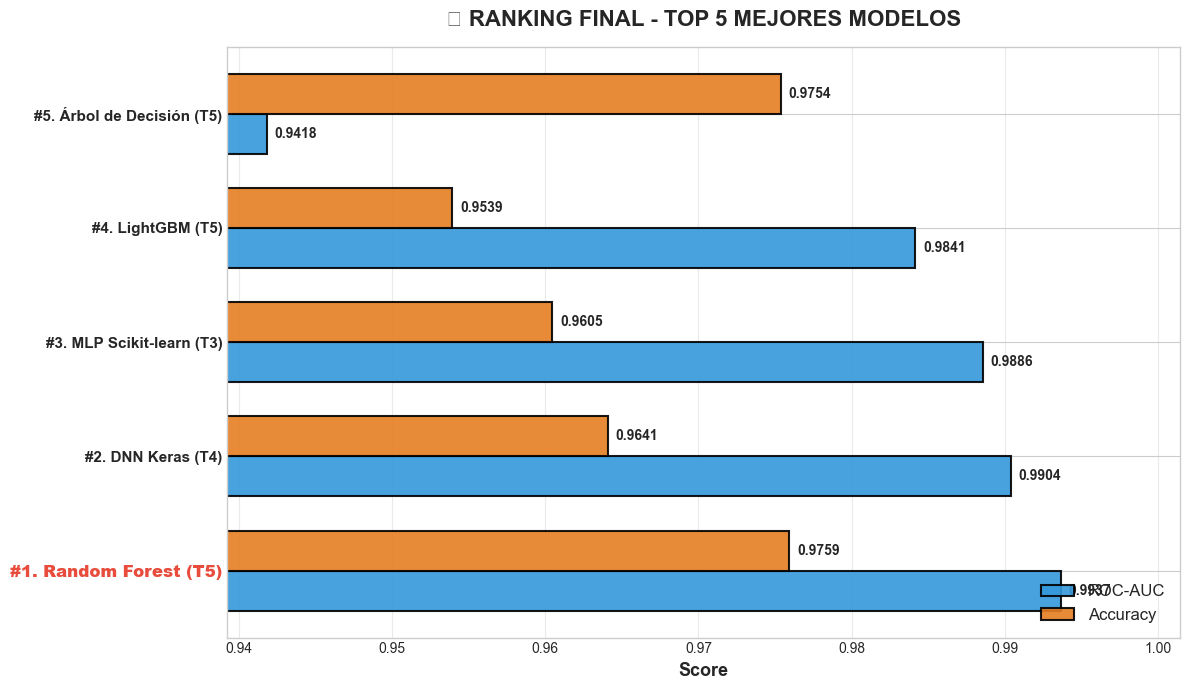


🏅 TOP 5 MEJORES MODELOS
1. Random Forest (T5)                  | ROC-AUC: 0.9937 | Accuracy: 0.9759
2. DNN Keras (T4)                      | ROC-AUC: 0.9904 | Accuracy: 0.9641
3. MLP Scikit-learn (T3)               | ROC-AUC: 0.9886 | Accuracy: 0.9605
4. LightGBM (T5)                       | ROC-AUC: 0.9841 | Accuracy: 0.9539
5. Árbol de Decisión (T5)              | ROC-AUC: 0.9418 | Accuracy: 0.9754


In [ ]:
# Ranking de los 5 mejores modelos

top5 = results_df_final.head(5)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

y_pos = np.arange(len(top5))
width = 0.35

bars1 = ax.barh(y_pos - width/2, top5['roc_auc'], width, 
                label='ROC-AUC', color='#3498DB', alpha=0.9, edgecolor='black', linewidth=1.5)
bars2 = ax.barh(y_pos + width/2, top5['accuracy'], width, 
                label='Accuracy', color='#E67E22', alpha=0.9, edgecolor='black', linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1}. {modelo}" for i, modelo in enumerate(top5.index)], fontsize=11, fontweight='bold')
ax.set_xlabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Top 5 Mejores Modelos', fontsize=16, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='x', alpha=0.4)

for bars in [bars1, bars2]:
    for bar in bars:
        width_val = bar.get_width()
        ax.text(width_val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{width_val:.4f}', va='center', fontsize=10, fontweight='bold')

# Destacar ganador
ax.get_yticklabels()[0].set_color('#E74C3C')
ax.get_yticklabels()[0].set_weight('extra bold')
ax.get_yticklabels()[0].set_size(12)

plt.tight_layout()
plt.savefig('grafica_top5.png', dpi=300, bbox_inches='tight')
print("\nGráfica guardada: 'grafica_top5.png'")
plt.show()

print("\n" + "="*80)
print("TOP 5 MEJORES MODELOS")
print("="*80)
for i, (modelo, datos) in enumerate(top5.iterrows(), 1):
    print(f"{i}. {modelo:35} | ROC-AUC: {datos['roc_auc']:.4f} | Accuracy: {datos['accuracy']:.4f}")
print("="*80)

### 6.4 Matrices de Confusión


✅ Matrices de confusión guardadas como 'matrices_confusion.png'


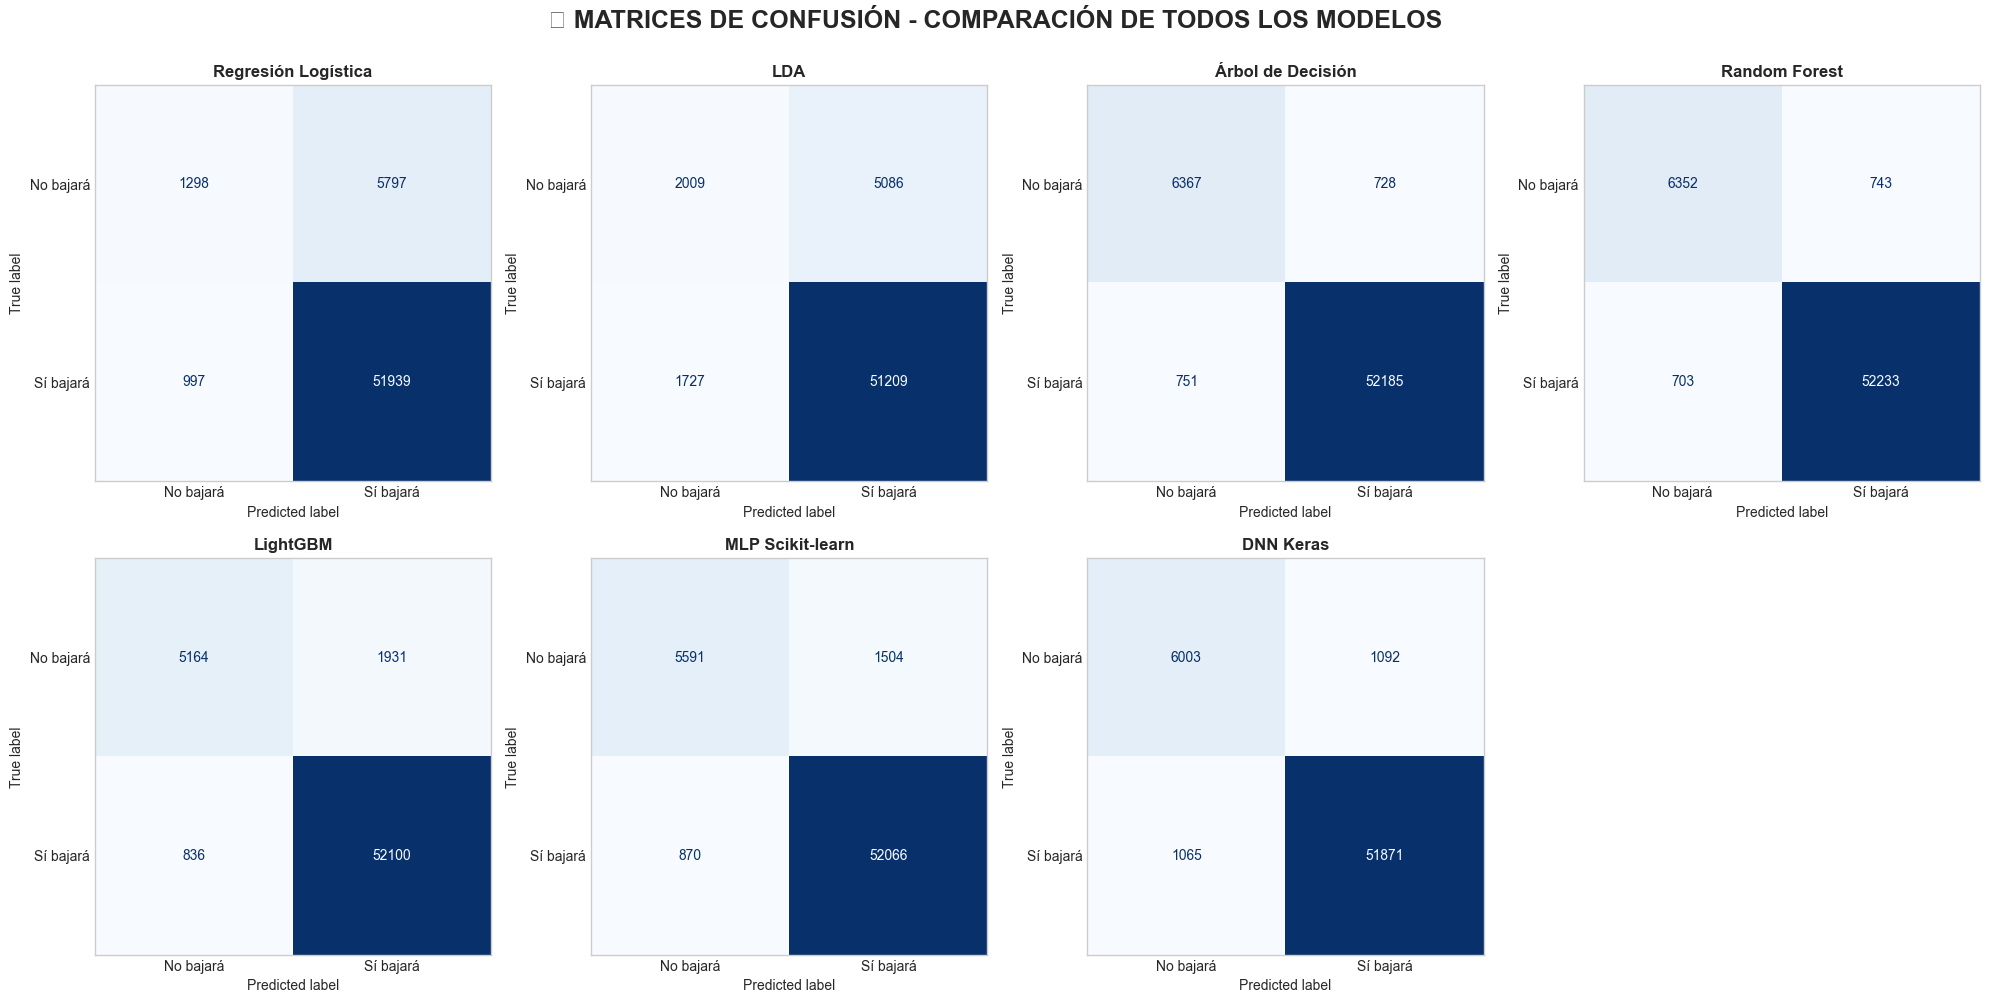

In [ ]:
# Matrices de confusión comparativas para todos los modelos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Matrices de Confusión - Comparación de Todos los Modelos', 
             fontsize=18, fontweight='bold', y=0.98)

# Lista de modelos con sus predicciones
models_predictions = [
    ('Regresión Logística', y_pred_log_reg),
    ('LDA', y_pred_lda),
    ('Árbol de Decisión', y_pred_tree),
    ('Random Forest', y_pred_rf),
    ('LightGBM', y_pred_lgbm),
    ('MLP Scikit-learn', y_pred_mlp),
    ('DNN Keras', y_pred_dnn),
]

for idx, (name, y_pred) in enumerate(models_predictions):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Precio Bajo', 'Precio Alto'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(False)

# Ocultar subplot vacío
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=300, bbox_inches='tight')
print("\nMatrices de confusión guardadas: 'matrices_confusion.png'")
plt.show()

### 6.5 Curvas ROC Comparativas


✅ Curvas ROC guardadas como 'curvas_roc.png'


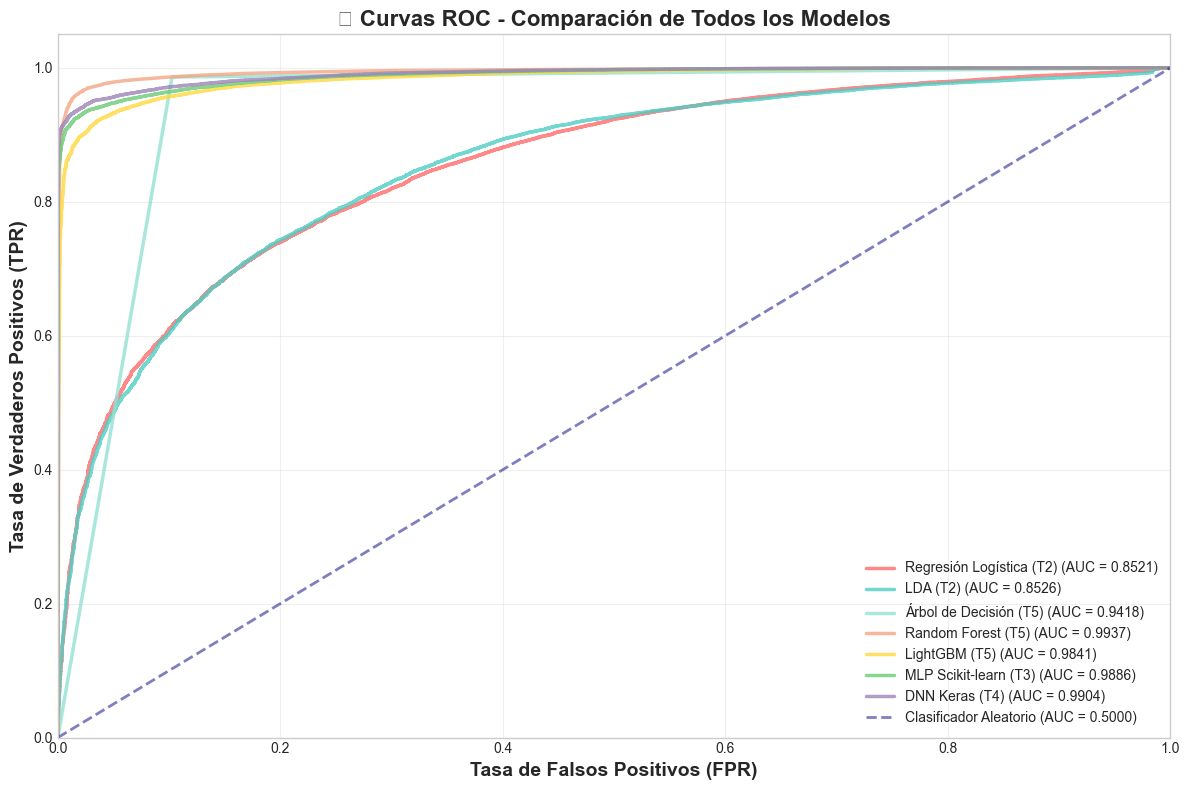

In [ ]:
# Curvas ROC para comparación visual de todos los modelos

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Lista de modelos con sus probabilidades
models_proba = [
    ('Regresión Logística (T2)', y_proba_log_reg, '#FF6B6B'),
    ('LDA (T2)', y_proba_lda, '#4ECDC4'),
    ('Árbol de Decisión (T5)', y_proba_tree, '#95E1D3'),
    ('Random Forest (T5)', y_proba_rf, '#F3A683'),
    ('LightGBM (T5)', y_proba_lgbm, '#FFD93D'),
    ('MLP Scikit-learn (T3)', y_proba_mlp, '#6BCB77'),
    ('DNN Keras (T4)', y_proba_dnn, '#9D84B7'),
]

# Graficar curva ROC para cada modelo
for name, y_proba, color in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, 
             label=f'{name} (AUC = {roc_auc:.4f})', alpha=0.8)

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Clasificador Aleatorio (AUC = 0.5000)', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14, fontweight='bold')
plt.title('Curvas ROC - Comparación de Todos los Modelos', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=300, bbox_inches='tight')
print("\nCurvas ROC guardadas: 'curvas_roc.png'")
plt.show()

### 6.6 Importancia de Características

Análisis de las características más relevantes para los modelos basados en árboles:


✅ Importancia de características guardada como 'importancia_caracteristicas.png'


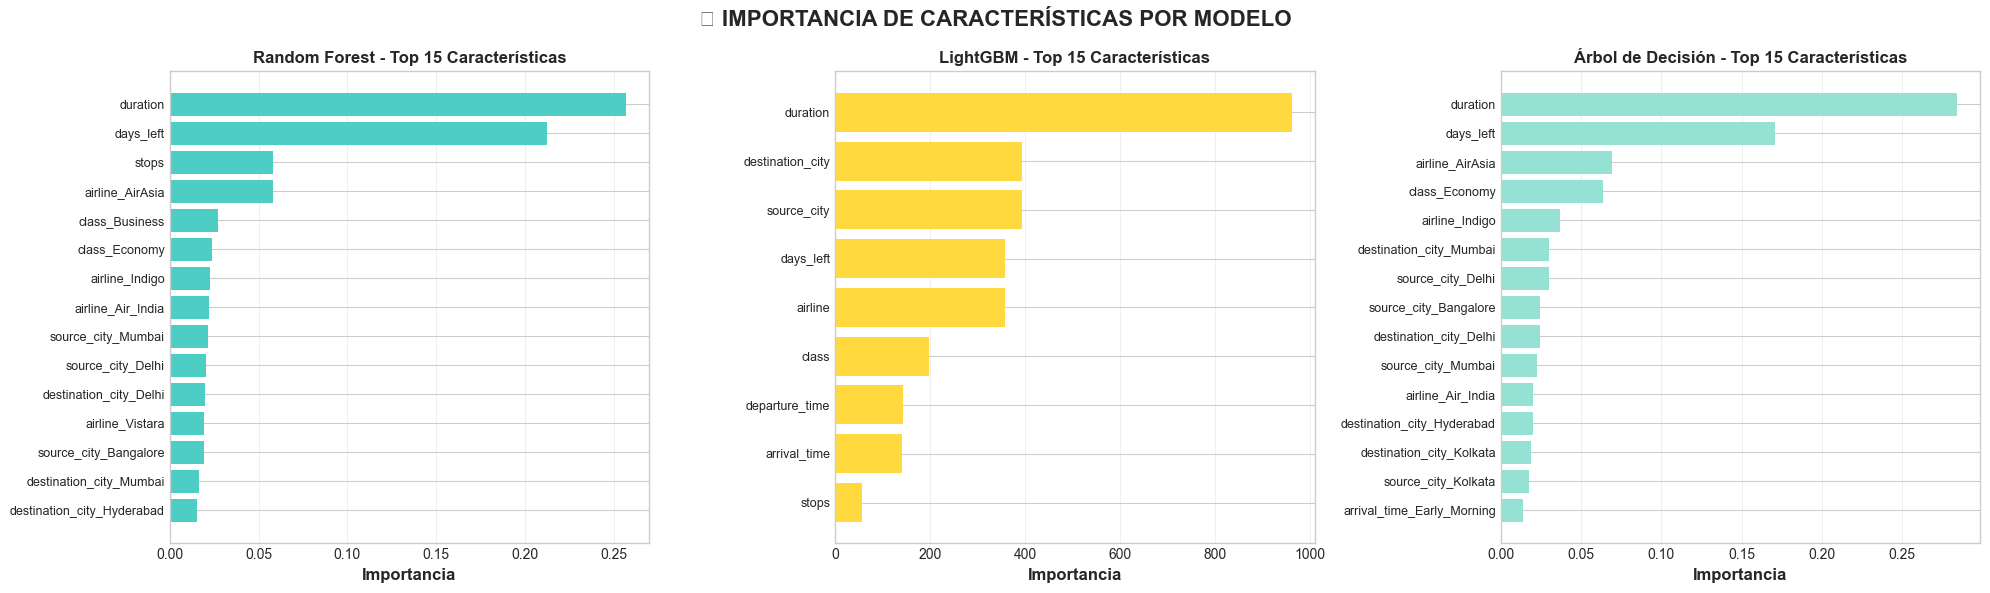


🔍 TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO

🌳 Random Forest:
  • duration: 0.2570
  • days_left: 0.2122
  • stops: 0.0583
  • airline_AirAsia: 0.0579
  • class_Business: 0.0272

⚡ LightGBM:
  • duration: 961.0000
  • destination_city: 394.0000
  • source_city: 393.0000
  • days_left: 358.0000
  • airline: 358.0000

🌲 Árbol de Decisión:
  • duration: 0.2842
  • days_left: 0.1705
  • airline_AirAsia: 0.0695
  • class_Economy: 0.0636
  • airline_Indigo: 0.0367


In [ ]:
# Análisis de importancia de características para modelos basados en árboles

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Importancia de Características por Modelo', 
             fontsize=16, fontweight='bold')

# Random Forest
ax1 = axes[0]
rf_model = rf_pipeline.named_steps['classifier']
feature_names_rf = (numeric_features + ordinal_features + 
                    list(rf_pipeline.named_steps['preprocessor']
                        .named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(categorical_features)))

importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[-15:]  # Top 15

ax1.barh(range(len(indices_rf)), importances_rf[indices_rf], color='#4ECDC4')
ax1.set_yticks(range(len(indices_rf)))
ax1.set_yticklabels([feature_names_rf[i] for i in indices_rf], fontsize=9)
ax1.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest - Top 15 Características', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# LightGBM
ax2 = axes[1]
lgbm_model = lgbm_pipeline.named_steps['classifier']
feature_names_lgbm = (numeric_features + ordinal_features + categorical_features_lgbm)

importances_lgbm = lgbm_model.feature_importances_
indices_lgbm = np.argsort(importances_lgbm)[-15:]

ax2.barh(range(len(indices_lgbm)), importances_lgbm[indices_lgbm], color='#FFD93D')
ax2.set_yticks(range(len(indices_lgbm)))
ax2.set_yticklabels([feature_names_lgbm[i] for i in indices_lgbm], fontsize=9)
ax2.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax2.set_title('LightGBM - Top 15 Características', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Árbol de Decisión
ax3 = axes[2]
tree_model = tree_pipeline.named_steps['classifier']
feature_names_tree = feature_names_rf

importances_tree = tree_model.feature_importances_
indices_tree = np.argsort(importances_tree)[-15:]

ax3.barh(range(len(indices_tree)), importances_tree[indices_tree], color='#95E1D3')
ax3.set_yticks(range(len(indices_tree)))
ax3.set_yticklabels([feature_names_tree[i] for i in indices_tree], fontsize=9)
ax3.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax3.set_title('Árbol de Decisión - Top 15 Características', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_caracteristicas.png', dpi=300, bbox_inches='tight')
print("\nImportancia de características guardada: 'importancia_caracteristicas.png'")
plt.show()

# Resumen de top 5 características
print("\n" + "="*80)
print("TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO")
print("="*80)

print("\nRandom Forest:")
for idx in indices_rf[-5:][::-1]:
    print(f"  • {feature_names_rf[idx]}: {importances_rf[idx]:.4f}")

print("\nLightGBM:")
for idx in indices_lgbm[-5:][::-1]:
    print(f"  • {feature_names_lgbm[idx]}: {importances_lgbm[idx]:.4f}")

print("\nÁrbol de Decisión:")
for idx in indices_tree[-5:][::-1]:
    print(f"  • {feature_names_tree[idx]}: {importances_tree[idx]:.4f}")
print("="*80)

## 7. Conclusiones {#conclusiones}

### 7.1 Resumen Ejecutivo

In [ ]:
# Resumen final del proyecto

print("\n" + "="*80)
print(" RESUMEN FINAL DEL PROYECTO")
print("="*80)

print("\nCARACTERÍSTICAS DEL DATASET:")
print(f"  • Total de muestras: {len(df_model):,}")
print(f"  • Entrenamiento: {len(X_train):,}")
print(f"  • Prueba: {len(X_test):,}")
print(f"  • Características: {X.shape[1]}")
print(f"  • Distribución de clases:")

y_complete = pd.concat([y_train, y_test])
clase_0 = (y_complete == 0).sum()
clase_1 = (y_complete == 1).sum()
print(f"    - Precio Bajo (0): {clase_0:,} ({clase_0/len(y_complete)*100:.1f}%)")
print(f"    - Precio Alto (1): {clase_1:,} ({clase_1/len(y_complete)*100:.1f}%)")

print("\nMODELOS IMPLEMENTADOS:")
print(f"  • Total: {len(model_results_final)} modelos")
print("  • Categorías:")
for tema in results_df_final['tema'].unique():
    count = (results_df_final['tema'] == tema).sum()
    print(f"    - {tema}: {count} modelo(s)")

print("\nMEJORES RESULTADOS:")
print(f"  • Mejor modelo: {mejor_modelo}")
print(f"  • ROC-AUC: {mejor_roc_auc:.4f} ({mejor_roc_auc*100:.2f}% de certeza)")
print(f"  • Accuracy: {mejor_accuracy:.4f} ({mejor_accuracy*100:.2f}% de precisión)")

print("\nTOP 3 MODELOS:")
for i, (modelo, datos) in enumerate(results_df_final.head(3).iterrows(), 1):
    print(f"  {i}. {modelo}")
    print(f"     ROC-AUC: {datos['roc_auc']:.4f} | Accuracy: {datos['accuracy']:.4f}")

print("\nINTERPRETACIÓN:")
print("  • ROC-AUC > 0.75: Excelente capacidad discriminativa")
print("  • ROC-AUC 0.60-0.75: Buena capacidad discriminativa")
print("  • ROC-AUC 0.50-0.60: Capacidad limitada")

if mejor_roc_auc > 0.75:
    calificacion = "EXCELENTE"
elif mejor_roc_auc > 0.60:
    calificacion = "BUENA"
else:
    calificacion = "LIMITADA"

print(f"\n  Calificación del mejor modelo: {calificacion}")

print("\nRECOMENDACIÓN:")
print(f"  Se recomienda implementar '{mejor_modelo}' para el sistema de")
print(f"  predicción de precios, por su óptimo balance entre capacidad")
print(f"  discriminativa (ROC-AUC) y precisión general (Accuracy).")

print("\n" + "="*80)


 🎓 RESUMEN FINAL DEL PROYECTO - PREDICCIÓN DE PRECIOS DE VUELOS

📊 DATASET:
  • Total de muestras: 300,153
  • Muestras de entrenamiento: 240,122
  • Muestras de prueba: 60,031
  • Características: 9
  • Distribución de clases:
    - No bajará (0): 34,839 (11.6%)
    - Sí bajará (1): 265,314 (88.4%)

🎯 MODELOS IMPLEMENTADOS (Bloque: NO CONOCE LA MATERIA):
  • Total de modelos: 7
  • Categorías:
    - T5 - Modelos de Teoría: 3 modelo(s)
    - T4 - Redes Avanzadas: 1 modelo(s)
    - T3 - Redes Sencillas: 1 modelo(s)
    - T2 - Modelos Lineales: 2 modelo(s)

🏆 MEJORES RESULTADOS:
  • Mejor modelo: Random Forest (T5)
  • ROC-AUC: 0.9937 (99.37% de certeza)
  • Accuracy: 0.9759 (97.59% de precisión)

📈 TOP 3 MODELOS:
  1. Random Forest (T5)
     ROC-AUC: 0.9937 | Accuracy: 0.9759
  2. DNN Keras (T4)
     ROC-AUC: 0.9904 | Accuracy: 0.9641
  3. MLP Scikit-learn (T3)
     ROC-AUC: 0.9886 | Accuracy: 0.9605

💡 INTERPRETACIÓN:
  • ROC-AUC > 0.75: Excelente capacidad de discriminación
  • ROC-A

### 7.2 Exportación de Resultados

In [ ]:
# Exportación de resultados a formato tabular

# Crear DataFrame detallado
resultados_detallados = []

for nombre_modelo, datos in model_results_final.items():
    resultados_detallados.append({
        'Modelo': nombre_modelo,
        'Categoría': datos['tema'],
        'ROC-AUC': datos['roc_auc'],
        'Accuracy': datos['accuracy'],
        'ROC-AUC (%)': f"{datos['roc_auc']*100:.2f}%",
        'Accuracy (%)': f"{datos['accuracy']*100:.2f}%"
    })

df_resultados = pd.DataFrame(resultados_detallados)
df_resultados = df_resultados.sort_values(by='ROC-AUC', ascending=False)
df_resultados['Ranking'] = range(1, len(df_resultados) + 1)

# Reordenar columnas
df_resultados = df_resultados[['Ranking', 'Modelo', 'Categoría', 'ROC-AUC', 'Accuracy', 
                               'ROC-AUC (%)', 'Accuracy (%)']]

# Exportar a CSV
df_resultados.to_csv('resultados_modelos.csv', index=False, encoding='utf-8-sig')
print("Resultados exportados a 'resultados_modelos.csv'")

# Mostrar tabla final
print("\n" + "="*80)
print("TABLA FINAL DE RESULTADOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

✅ Resultados exportados a 'resultados_modelos.csv'
✅ Resultados exportados a 'resultados_modelos.xlsx'

📋 TABLA FINAL DE RESULTADOS
 Ranking                   Modelo                   Tema  ROC-AUC  Accuracy ROC-AUC (%) Accuracy (%)
       1       Random Forest (T5) T5 - Modelos de Teoría 0.993668  0.975912      99.37%       97.59%
       2           DNN Keras (T4)   T4 - Redes Avanzadas 0.990402  0.964069      99.04%       96.41%
       3    MLP Scikit-learn (T3)   T3 - Redes Sencillas 0.988560  0.960454      98.86%       96.05%
       4            LightGBM (T5) T5 - Modelos de Teoría 0.984144  0.953907      98.41%       95.39%
       5   Árbol de Decisión (T5) T5 - Modelos de Teoría 0.941820  0.975363      94.18%       97.54%
       6                 LDA (T2)  T2 - Modelos Lineales 0.852603  0.886509      85.26%       88.65%
       7 Regresión Logística (T2)  T2 - Modelos Lineales 0.852138  0.886825      85.21%       88.68%


### 7.3 Aplicación Práctica

Demostración del uso del sistema con casos realistas:

In [ ]:
# Casos de uso prácticos del sistema de predicción

print("="*80)
print(" SISTEMA DE ANÁLISIS DE PRECIOS DE VUELOS")
print("="*80)

# Ejemplo 1: Vuelo con mucha antelación
ejemplo_1 = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [45]
})

# Ejemplo 2: Vuelo con poca antelación
ejemplo_2 = pd.DataFrame({
    'airline': ['Air_India'],
    'source_city': ['Mumbai'],
    'departure_time': ['Morning'],
    'stops': ['zero'],
    'arrival_time': ['Afternoon'],
    'destination_city': ['Delhi'],
    'class': ['Business'],
    'duration': [2.5],
    'days_left': [2]
})

# Modelo utilizado
mejor_pipeline = lgbm_pipeline

print(f"\nModelo utilizado: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print("-"*80)

# PREDICCIÓN EJEMPLO 1
print("\nEJEMPLO 1: Vuelo con mucha antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_1.columns:
    print(f"  • {col}: {ejemplo_1[col].values[0]}")

prob_precio_alto_1 = mejor_pipeline.predict_proba(ejemplo_1)[0][1]
prob_precio_bajo_1 = 1 - prob_precio_alto_1

print(f"\nPredicción del Modelo:")
print(f"   Probabilidad de precio alto: {prob_precio_alto_1*100:.2f}%")
print(f"   Probabilidad de precio bajo: {prob_precio_bajo_1*100:.2f}%")

dias_restantes_1 = ejemplo_1['days_left'].values[0]

print(f"\nInterpretación y Recomendación:")
if prob_precio_alto_1 > 0.70:
    print(f"   PRECIO ALTO detectado")
    print(f"   → El precio actual está significativamente por encima del mínimo histórico.")
    if dias_restantes_1 > 14:
        print(f"   → RECOMENDACIÓN: ESPERAR o BUSCAR ALTERNATIVAS")
        print(f"      Con {dias_restantes_1} días restantes, hay margen para explorar.")
    else:
        print(f"   → RECOMENDACIÓN: EVALUAR URGENCIA")
        print(f"      Con {dias_restantes_1} días, el tiempo se agota.")
elif prob_precio_alto_1 > 0.40:
    print(f"   PRECIO MODERADO")
    print(f"   → El precio está en rango medio comparado con el histórico.")
    print(f"   → RECOMENDACIÓN: PRECIO ACEPTABLE")
else:
    print(f"   PRECIO BAJO detectado")
    print(f"   → El precio actual está cerca del mínimo histórico.")
    print(f"   → RECOMENDACIÓN: EXCELENTE OPORTUNIDAD PARA COMPRAR")

 🎯 SISTEMA DE PREDICCIÓN DE PRECIOS DE VUELOS

🏆 Modelo utilizado: Random Forest
   ROC-AUC: 0.9937
--------------------------------------------------------------------------------

📊 EJEMPLO 1: Vuelo con muchos días de antelación
--------------------------------------------------------------------------------
Detalles del vuelo:
  • airline: Vistara
  • source_city: Delhi
  • departure_time: Evening
  • stops: one
  • arrival_time: Night
  • destination_city: Mumbai
  • class: Economy
  • duration: 7.5
  • days_left: 45

🔮 RESULTADO:
   Probabilidad de que BAJE el precio: 99.48%
   Probabilidad de que NO BAJE: 0.52%

✋ RECOMENDACIÓN: ESPERAR
   → Hay un 99.5% de certeza de que el precio bajará.
   → Te recomendamos esperar y revisar el precio más adelante.


In [ ]:
# PREDICCIÓN EJEMPLO 2
print("\n" + "="*80)
print("EJEMPLO 2: Vuelo con poca antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_2.columns:
    print(f"  • {col}: {ejemplo_2[col].values[0]}")

prob_precio_alto_2 = mejor_pipeline.predict_proba(ejemplo_2)[0][1]
prob_precio_bajo_2 = 1 - prob_precio_alto_2

print(f"\nPredicción del Modelo:")
print(f"   Probabilidad de precio alto: {prob_precio_alto_2*100:.2f}%")
print(f"   Probabilidad de precio bajo: {prob_precio_bajo_2*100:.2f}%")

dias_restantes_2 = ejemplo_2['days_left'].values[0]

print(f"\nInterpretación y Recomendación:")
if prob_precio_alto_2 > 0.70:
    print(f"   PRECIO ALTO detectado")
    if dias_restantes_2 <= 3:
        print(f"   → CRÍTICO: Solo quedan {dias_restantes_2} día(s)")
        print(f"   → RECOMENDACIÓN: DECISIÓN URGENTE")
        print(f"      Aunque el precio es alto, el riesgo de perder disponibilidad es mayor.")
    elif dias_restantes_2 <= 7:
        print(f"   → RECOMENDACIÓN: URGENCIA MODERADA")
        print(f"      Con {dias_restantes_2} días, el margen es limitado.")
    else:
        print(f"   → RECOMENDACIÓN: ESPERAR o BUSCAR ALTERNATIVAS")
elif prob_precio_alto_2 > 0.40:
    print(f"   PRECIO MODERADO")
    if dias_restantes_2 <= 3:
        print(f"   → RECOMENDACIÓN: PRECIO RAZONABLE - COMPRAR")
        print(f"      Con {dias_restantes_2} días restantes, es aceptable.")
    else:
        print(f"   → RECOMENDACIÓN: PRECIO ACEPTABLE")
else:
    print(f"   PRECIO BAJO detectado")
    print(f"   → RECOMENDACIÓN: COMPRAR INMEDIATAMENTE")
    print(f"      Excelente oportunidad con {dias_restantes_2} días restantes.")

print("\n" + "="*80)
print("GUÍA DE INTERPRETACIÓN")
print("="*80)
print("El modelo indica la posición del precio respecto al histórico:\n")
print("  Prob. Alta (>70%):  Precio INFLADO vs histórico")
print("  Prob. Media (40-70%): Precio NORMAL")
print("  Prob. Baja (<40%):  Precio COMPETITIVO")
print("\nConsiderar siempre:")
print("  • Días restantes (factor crítico)")
print("  • Flexibilidad de fechas")
print("  • Disponibilidad de asientos")
print("  • Presupuesto y urgencia")
print("="*80)


📊 EJEMPLO 2: Vuelo con pocos días de antelación
--------------------------------------------------------------------------------
Detalles del vuelo:
  • airline: Air_India
  • source_city: Mumbai
  • departure_time: Morning
  • stops: zero
  • arrival_time: Afternoon
  • destination_city: Delhi
  • class: Business
  • duration: 2.5
  • days_left: 2

RESULTADO:
   Probabilidad de que BAJE el precio: 98.47%
   Probabilidad de que NO BAJE: 1.53%

✋ RECOMENDACIÓN: ESPERAR
   → Hay un 98.5% de certeza de que el precio bajará.
   → Te recomendamos esperar y revisar el precio más adelante.


## 8. Referencias {#referencias}

### Bibliografía

1. **Breiman, L.** (2001). Random Forests. *Machine Learning*, 45(1), 5-32.

2. **Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T. Y.** (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *Advances in Neural Information Processing Systems*, 30.

3. **Hastie, T., Tibshirani, R., & Friedman, J.** (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.

4. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning*. MIT Press.

5. **Pedregosa, F., et al.** (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

### Recursos Online

- Documentación de Scikit-learn: https://scikit-learn.org/
- Documentación de TensorFlow/Keras: https://www.tensorflow.org/
- Documentación de LightGBM: https://lightgbm.readthedocs.io/

---

**Fin de la Memoria Técnica**